# Hospital prescriptions dispensed in the community
## Data overview for `ebmdatalab.hospitalcommunityprescribing.hospital_community_rx`

This notebook provides a tour of the hospital prescriptions dispensed in the community dataset.

Screenshot of table schema from big query:

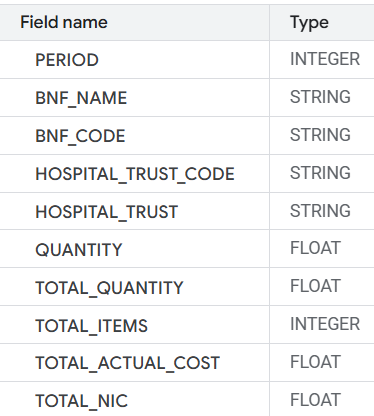

We'll start by connecting to BigQuery, then move through:
- the overall shape and date coverage
- how many organisations, products, rows, and items we see over time
- the top products and the distribution of items by hospital trust

The aim is to help  users quickly understand what is available.


## Setting up the analysis environment

We will use:
- `ebmdatalab.bq` to run BigQuery queries and optionally cache results locally
- `pandas` for working with tabular outputs
- `matplotlib` for charts



In [37]:
from ebmdatalab import bq
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from IPython.display import display

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", 100)

# Local cache folder for query outputs 
CACHE_DIR = "../hospital_community_rx_data"
os.makedirs(CACHE_DIR, exist_ok=True)

TABLE_ID = "ebmdatalab.hospitalcommunityprescribing.hospital_community_rx"

#added later to display numbers better
pd.set_option("display.float_format", "{:,.0f}".format)


## Quick schema check

Validating column names and types by viewing a small sample. This also gives us a quick feel for what a single row looks like.

In [2]:
sql_sample = f'''
SELECT *
FROM `{TABLE_ID}`
LIMIT 10
'''

df_sample = bq.cached_read(
    sql_sample,
    csv_path=os.path.join(CACHE_DIR, "sample_10_rows.csv"),
)

display(df_sample)


,PERIOD,BNF_NAME,BNF_CODE,HOSPITAL_TRUST_CODE,HOSPITAL_TRUST,QUANTITY,TOTAL_QUANTITY,TOTAL_ITEMS,TOTAL_ACTUAL_COST,TOTAL_NIC
0,202402,Omeprazole 20mg gastro-resistant capsules,0103050P0AAAAAA,R0A00,MANCHESTER UNIVERSITY NHS FOUNDATION TRUST,7.0,77.0,11,5.589798,4.62
1,202402,Bisoprolol 2.5mg tablets,0204000H0AAAJAJ,R0A00,MANCHESTER UNIVERSITY NHS FOUNDATION TRUST,28.0,168.0,6,6.180465,6.48
2,202402,Montelukast 4mg chewable tablets sugar free,0303020G0AAACAC,R0A00,MANCHESTER UNIVERSITY NHS FOUNDATION TRUST,42.0,42.0,1,1.554110,1.53
3,202402,Quetiapine 50mg modified-release tablets,0402010ABAAAVAV,R0A00,MANCHESTER UNIVERSITY NHS FOUNDATION TRUST,30.0,60.0,2,63.980413,67.66
4,202402,Equasym XL 10mg capsules,0404000M0BCADAU,R0A00,MANCHESTER UNIVERSITY NHS FOUNDATION TRUST,15.0,15.0,1,11.891075,12.50
5,202402,Elvanse 60mg capsules,0404000U0BCAFAE,R0A00,MANCHESTER UNIVERSITY NHS FOUNDATION TRUST,28.0,28.0,1,70.854064,75.18
6,202402,Phenoxymethylpenicillin 250mg tablets,0501011P0AAAJAJ,R0A00,MANCHESTER UNIVERSITY NHS FOUNDATION TRUST,40.0,240.0,6,17.070316,17.40
7,202402,Clarithromycin 500mg tablets,0501050B0AAADAD,R0A00,MANCHESTER UNIVERSITY NHS FOUNDATION TRUST,15.0,15.0,1,7.820365,8.18
8,202402,Fludrocortisone 100microgram tablets,0603010I0AAACAC,R0A00,MANCHESTER UNIVERSITY NHS FOUNDATION TRUST,28.0,28.0,1,5.050021,5.24
9,202402,Ciclosporin 50mg capsules,0802020G0AAAFAF,R0A00,MANCHESTER UNIVERSITY NHS FOUNDATION TRUST,42.0,42.0,1,28.871213,30.52


## Date coverage and how many months are available

We can see from the schema, that `PERIOD` is an integer.

We'll confirm:
- first and last available month
- number of distinct months and years
- total calendar span in months and years
- boolean flag indicating whether the data are continuous with no missing months.


In [3]:
sql_coverage = f'''
SELECT
  -- Earliest available period in the dataset (format assumed YYYYMM)
  MIN(PERIOD) AS min_period,

  -- Latest available period in the dataset (format assumed YYYYMM)
  MAX(PERIOD) AS max_period,

  -- Number of distinct monthly periods actually present in the data
  COUNT(DISTINCT PERIOD) AS n_months,

  -- Number of distinct years present.
  -- FLOOR(PERIOD/100) extracts the YYYY part from a YYYYMM integer.
  COUNT(DISTINCT CAST(FLOOR(PERIOD/100) AS INT64)) AS n_years,

  -- Total number of months between first and last period (inclusive).
  -- Step 1: Extract year from MAX and MIN (YYYY)
  -- Step 2: Compute year difference and convert to months (* 12)
  -- Step 3: Extract month component using MOD(PERIOD, 100)
  -- Step 4: Add month difference
  -- Step 5: Add 1 to make the span inclusive of both endpoints
  (CAST(FLOOR(MAX(PERIOD)/100) AS INT64) 
     - CAST(FLOOR(MIN(PERIOD)/100) AS INT64)) * 12
    + (MOD(MAX(PERIOD), 100) 
     - MOD(MIN(PERIOD), 100)) + 1 AS n_months_span,

  -- Same span expressed in years (rounded to 1 decimal place).
  -- Division by 12.0 forces floating point division.
  ROUND(
    (
      (CAST(FLOOR(MAX(PERIOD)/100) AS INT64) 
        - CAST(FLOOR(MIN(PERIOD)/100) AS INT64)) * 12
      + (MOD(MAX(PERIOD), 100) 
        - MOD(MIN(PERIOD), 100)) + 1
    ) / 12.0,
  1) AS n_years_span,

  -- Boolean check for gaps in the time series.
  -- If the number of distinct months present equals the calculated
  -- inclusive month span, then there are no missing months.
  COUNT(DISTINCT PERIOD) = 
    (
      (CAST(FLOOR(MAX(PERIOD)/100) AS INT64) 
        - CAST(FLOOR(MIN(PERIOD)/100) AS INT64)) * 12
      + (MOD(MAX(PERIOD), 100) 
        - MOD(MIN(PERIOD), 100)) + 1
    ) AS no_gaps

-- Target table (injected via Python f-string)
FROM `{TABLE_ID}`
'''

In [4]:
df_coverage = bq.cached_read(
    sql_coverage,
    csv_path=os.path.join(CACHE_DIR, "coverage.csv"),
)
df_coverage

,min_period,max_period,n_months,n_years,n_months_span,n_years_span,no_gaps
0,201612,202509,106,10,106,8.8,True


`n_years` counts the number of distinct calendar years that appear in the data. In this case, the dataset includes observations in 10 different years.

`n_years_span`, however, measures the total time between the first and last month in the series, expressed in years. Although the data touches 10 separate calendar years, the actual continuous time span from December 2016 to September 2025 is 8.8 years.

## Rows per month


,PERIOD,n_rows,date
0,201612,151994,2016-12-01
1,201701,151799,2017-01-01
2,201702,145680,2017-02-01
3,201703,158023,2017-03-01
4,201704,142645,2017-04-01


,PERIOD,n_rows,date
101,202505,175133,2025-05-01
102,202506,174079,2025-06-01
103,202507,175370,2025-07-01
104,202508,165783,2025-08-01
105,202509,172552,2025-09-01


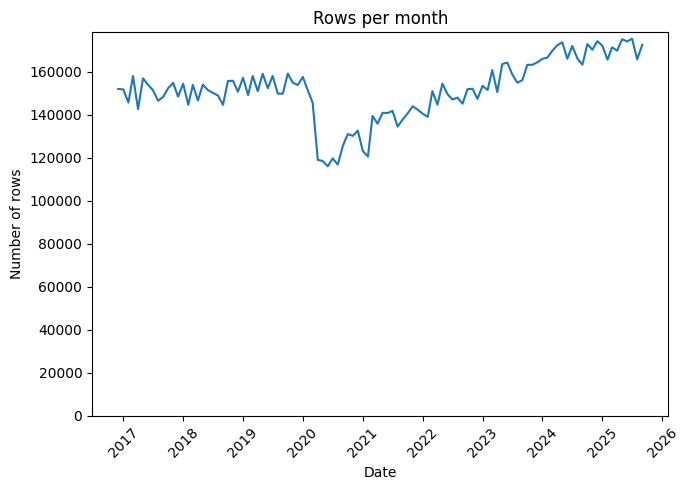

In [49]:
sql_rows_per_month = f'''
SELECT
  PERIOD,
  COUNT(*) AS n_rows
FROM `{TABLE_ID}`
GROUP BY PERIOD
ORDER BY PERIOD
'''
df_rows_per_month = bq.cached_read(
    sql_rows_per_month,
    csv_path=os.path.join(CACHE_DIR, "rows_per_month.csv"),
)
# convert PERIOD to a proper datetime before plotting
df_rows_per_month["date"] = pd.to_datetime(
    df_rows_per_month["PERIOD"].astype(str), format="%Y%m"
)
display(df_rows_per_month.head())
display(df_rows_per_month.tail())
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(df_rows_per_month["date"], df_rows_per_month["n_rows"])
ax.set_xlabel("Date")
ax.set_ylabel("Number of rows")
ax.tick_params(axis="x", rotation=45)
ax.set_ylim(bottom=0)
ax.set_title("Rows per month")
plt.tight_layout()
plt.show()

>  **NB:** We observe is a big reduction in number of rows between 2019 and 2020. 

## How many hospital trusts appear in the data?

We'll look at:
- how many distinct trusts exist overall
- how many are active each month


Distinct hospital trusts overall: 241


,PERIOD,n_trusts_active,date
0,201612,217,2016-12-01
1,201701,220,2017-01-01
2,201702,219,2017-02-01
3,201703,218,2017-03-01
4,201704,220,2017-04-01


,PERIOD,n_trusts_active,date
101,202505,192,2025-05-01
102,202506,189,2025-06-01
103,202507,190,2025-07-01
104,202508,191,2025-08-01
105,202509,190,2025-09-01


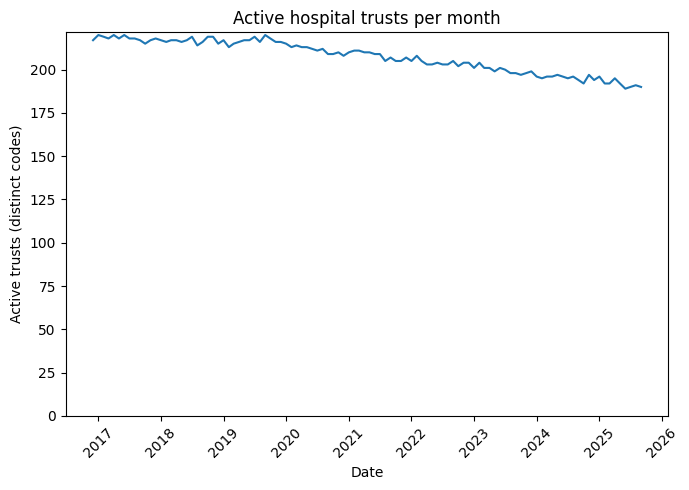

In [42]:
sql_trust_counts = f'''
WITH overall AS (
  SELECT
    COUNT(DISTINCT HOSPITAL_TRUST_CODE) AS n_trusts_overall
  FROM `{TABLE_ID}`
),
by_month AS (
  SELECT
    PERIOD,
    COUNT(DISTINCT HOSPITAL_TRUST_CODE) AS n_trusts_active
  FROM `{TABLE_ID}`
  GROUP BY PERIOD
)
SELECT
  o.n_trusts_overall,
  b.PERIOD,
  b.n_trusts_active
FROM overall o
CROSS JOIN by_month b
ORDER BY b.PERIOD
'''
df_trust_counts = bq.cached_read(
    sql_trust_counts,
    csv_path=os.path.join(CACHE_DIR, "trust_counts.csv"),
)
n_trusts_overall = int(df_trust_counts["n_trusts_overall"].iloc[0])
print(f"Distinct hospital trusts overall: {n_trusts_overall:,}")
df_trust_active = df_trust_counts[["PERIOD", "n_trusts_active"]].copy()
# convert PERIOD to a proper datetime before plotting
df_trust_active["date"] = pd.to_datetime(
    df_trust_active["PERIOD"].astype(str), format="%Y%m"
)
display(df_trust_active.head())
display(df_trust_active.tail())
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(df_trust_active["date"], df_trust_active["n_trusts_active"])
ax.set_xlabel("Date")
ax.set_ylabel("Active trusts (distinct codes)")
ax.tick_params(axis="x", rotation=45)
ax.set_ylim(bottom=0)
ax.set_title("Active hospital trusts per month")
plt.tight_layout()
plt.show()

- **241** distinct trust codes exist in the dataset
- the number of active trusts in a given month was closer to **~190** in the latest months

That drop in active trusts over time could be organisational mergers or code changes.

## How many presentations are available?

We'll use `BNF_CODE` as the product identifier, and also check the number of unique names.


Downloading: 100%|█████████████████████████████████████████████████████████████|


,PERIOD,n_presentations,n_presentation_names,date
0,201612,5812,5811,2016-12-01
1,201701,5907,5906,2017-01-01
2,201702,5844,5843,2017-02-01
3,201703,6036,6035,2017-03-01
4,201704,5732,5730,2017-04-01


,PERIOD,n_presentations,n_presentation_names,date
101,202505,5728,5728,2025-05-01
102,202506,5767,5767,2025-06-01
103,202507,5784,5784,2025-07-01
104,202508,5606,5606,2025-08-01
105,202509,5738,5738,2025-09-01


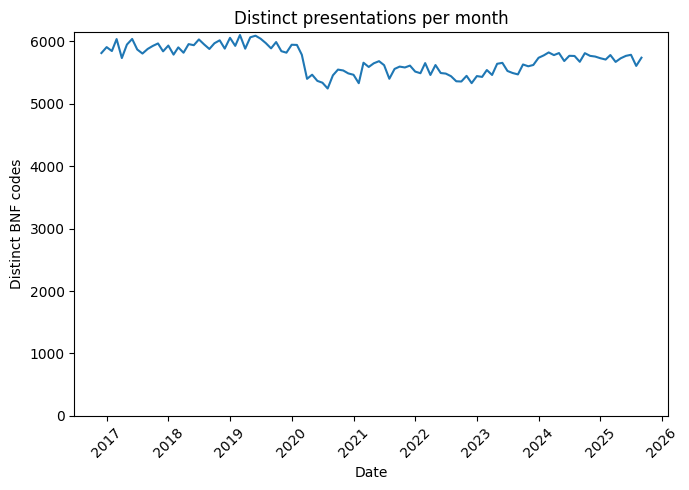

In [60]:
sql_presentation_counts = f'''
SELECT
  PERIOD,
  COUNT(DISTINCT BNF_CODE) AS n_presentations,
  COUNT(DISTINCT BNF_NAME) AS n_presentation_names
FROM `{TABLE_ID}`
GROUP BY PERIOD
ORDER BY PERIOD
'''
df_presentation_counts = bq.cached_read(
    sql_presentation_counts,
    csv_path=os.path.join(CACHE_DIR, "presentation_counts.csv"),
)
# convert PERIOD to a proper datetime before plotting
df_presentation_counts["date"] = pd.to_datetime(
    df_presentation_counts["PERIOD"].astype(str), format="%Y%m"
)
display(df_presentation_counts.head())
display(df_presentation_counts.tail())
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(df_presentation_counts["date"], df_presentation_counts["n_presentations"])
ax.set_xlabel("Date")
ax.set_ylabel("Distinct BNF codes")
ax.tick_params(axis="x", rotation=45)
ax.set_ylim(bottom=0)
ax.set_title("Distinct presentations per month")
plt.tight_layout()
plt.show()

## Number of items over time (national)

We'll calculate total items and cost (actual cost and NIC) per month.


,PERIOD,total_items,total_actual_cost,total_nic,date
0,201612,383609,"10,652,906","11,468,920",2016-12-01
1,201701,383787,"11,055,221","11,891,939",2017-01-01
2,201702,362377,"9,760,441","10,490,243",2017-02-01
3,201703,412318,"10,799,654","11,624,228",2017-03-01
4,201704,352990,"9,325,545","10,025,454",2017-04-01


,PERIOD,total_items,total_actual_cost,total_nic,date
101,202505,499041,"9,510,088","9,850,565",2025-05-01
102,202506,496087,"9,683,535","10,025,022",2025-06-01
103,202507,509756,"9,941,753","10,284,796",2025-07-01
104,202508,464342,"8,749,052","9,056,036",2025-08-01
105,202509,492016,"9,687,347","10,022,189",2025-09-01


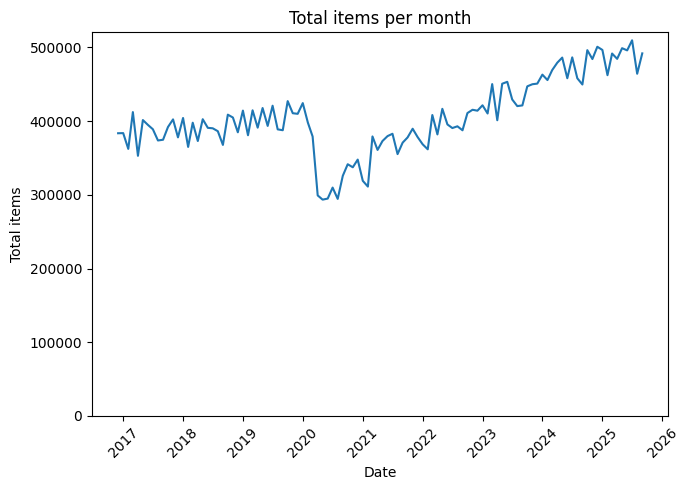

In [50]:
sql_items_cost_per_month = f'''
SELECT
  PERIOD,
  SUM(TOTAL_ITEMS) AS total_items,
  SUM(TOTAL_ACTUAL_COST) AS total_actual_cost,
  SUM(TOTAL_NIC) AS total_nic
FROM `{TABLE_ID}`
GROUP BY PERIOD
ORDER BY PERIOD
'''
df_items_cost_per_month = bq.cached_read(
    sql_items_cost_per_month,
    csv_path=os.path.join(CACHE_DIR, "items_cost_per_month.csv"),
)
# convert PERIOD to a proper datetime before plotting
df_items_cost_per_month["date"] = pd.to_datetime(
    df_items_cost_per_month["PERIOD"].astype(str), format="%Y%m"
)
display(df_items_cost_per_month.head())
display(df_items_cost_per_month.tail())
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(df_items_cost_per_month["date"], df_items_cost_per_month["total_items"])
ax.set_xlabel("Date")
ax.set_ylabel("Total items")
ax.tick_params(axis="x", rotation=45)
ax.set_ylim(bottom=0)
ax.set_title("Total items per month")
plt.tight_layout()
plt.show()

## Item distribution by trust (latest month)

Which hospital trusts account for the most community-dispensed items?

We'll identify the latest available month, then:
- rank trusts by total items
- show the top 20



Latest PERIOD in the table: 202509


,PERIOD,HOSPITAL_TRUST_CODE,HOSPITAL_TRUST,total_items,total_actual_cost
0,202509,RRE00,MIDLANDS PARTNERSHIP UNIVERSITY NHS FOUNDATION TRUST,20052,361488.29998
1,202509,RDU00,FRIMLEY HEALTH NHS FOUNDATION TRUST,15013,217872.72059
2,202509,RXK00,SANDWELL AND WEST BIRMINGHAM HOSPITALS NHS TRUST,13559,312812.52383
3,202509,RX300,TEES ESK AND WEAR VALLEYS NHS FOUNDATION TRUST,12707,178704.99136
4,202509,RVV00,EAST KENT HOSPITALS UNIVERSITY NHS FOUNDATION TRUST,12320,299915.81512
5,202509,RYR00,UNIVERSITY HOSPITALS SUSSEX NHS FOUNDATION TRUST,10443,179449.78334
6,202509,RC900,BEDFORDSHIRE HOSPITALS NHS FOUNDATION TRUST,10087,219502.30997
7,202509,RXT00,B'HAM & S'HULL MH NHS FOUNDATION TRUST,10065,177348.48459
8,202509,RX400,CUMBRIANORTHUMBERLANDTYNE AND WEAR NHS FOUNDATION TRUST,9688,194216.06286
9,202509,RK500,SHERWOOD FOREST HOSPITALS NHS FOUNDATION TRUST,9121,106754.05287


Top 20 trusts share of items in 202509: 40.1%


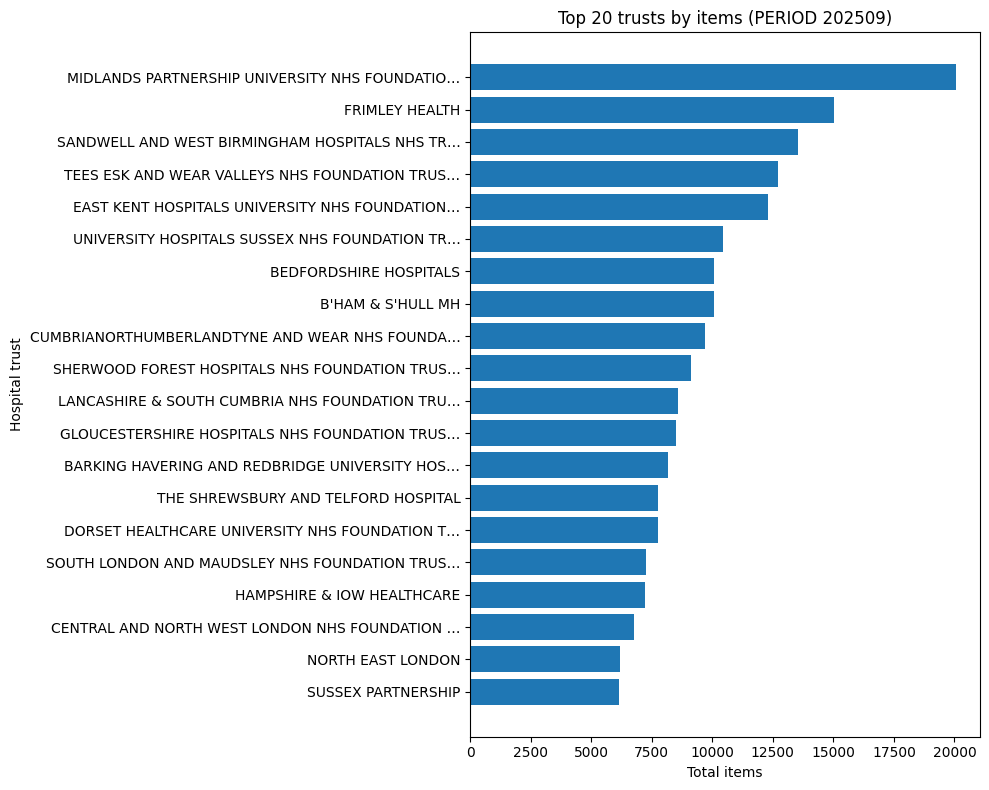

In [9]:
latest_period = int(df_rows_per_month["PERIOD"].max())
print(f"Latest PERIOD in the table: {latest_period}")

sql_items_by_trust_latest = f'''
SELECT
  PERIOD,
  HOSPITAL_TRUST_CODE,
  ANY_VALUE(HOSPITAL_TRUST) AS HOSPITAL_TRUST,
  SUM(TOTAL_ITEMS) AS total_items,
  SUM(TOTAL_ACTUAL_COST) AS total_actual_cost
FROM `{TABLE_ID}`
WHERE PERIOD = {latest_period}
GROUP BY PERIOD, HOSPITAL_TRUST_CODE
ORDER BY total_items DESC
'''

df_items_by_trust_latest = bq.cached_read(
    sql_items_by_trust_latest,
    csv_path=os.path.join(CACHE_DIR, f"items_by_trust_{latest_period}.csv"),
)

display(df_items_by_trust_latest.head(20))

top20 = df_items_by_trust_latest.head(20).copy()
total_items_latest = df_items_by_trust_latest["total_items"].sum()
top20_share = top20["total_items"].sum() / total_items_latest if total_items_latest else np.nan

print(f"Top 20 trusts share of items in {latest_period}: {top20_share:.1%}")

# Truncate long name for chart (keep first N chars + ellipsis)
import textwrap
def truncate_name(name, max_len=45):
    return name[:max_len] + "…" if len(name) > max_len else name
top20["SHORT_NAME"] = top20["HOSPITAL_TRUST"].apply(truncate_name)

# Remove redundant suffix that appears on almost every trust
top20["SHORT_NAME"] = (
    top20["SHORT_NAME"]
    .str.replace(r"\s*(NHS FOUNDATION TRUST|NHS TRUST|NHS F TRUST)\s*$", "", regex=True)
    .str.strip()
)

fig, ax = plt.subplots(figsize=(10, 8))  # wider and taller
ax.barh(top20["SHORT_NAME"][::-1], top20["total_items"][::-1])
ax.set_xlabel("Total items")
ax.set_ylabel("Hospital trust")
ax.set_title(f"Top 20 trusts by items (PERIOD {latest_period})")
plt.tight_layout()
plt.show()


## Top presentations

We'll identify top products by:
- items (volume)
- actual cost (spend)

We'll show:
- top 20 in the latest month
- top 20 over the most recent 12 months 


In [10]:
# Build a list of the latest N periods available
periods_sorted = df_rows_per_month["PERIOD"].sort_values().tolist()
latest_12_periods = periods_sorted[-12:] if len(periods_sorted) >= 12 else periods_sorted

print(f"Using {len(latest_12_periods)} months for the 'recent period' analysis.")
print(f"From {latest_12_periods[0]} to {latest_12_periods[-1]}")

period_list_sql = ", ".join(str(p) for p in latest_12_periods)


Using 12 months for the 'recent period' analysis.
From 202410 to 202509


### Top presentations by items (latest month)


In [56]:
sql_top_presentations_items_latest = f'''
SELECT
  BNF_CODE,
  ANY_VALUE(BNF_NAME) AS BNF_NAME,
  SUM(TOTAL_ITEMS) AS total_items,
  SUM(TOTAL_ACTUAL_COST) AS total_actual_cost
FROM `{TABLE_ID}`
WHERE PERIOD = {latest_period}
GROUP BY BNF_CODE
ORDER BY total_items DESC
LIMIT 20
'''

df_top_presentations_items_latest = bq.cached_read(
    sql_top_presentations_items_latest,
    csv_path=os.path.join(CACHE_DIR, f"top_presentations_items_{latest_period}.csv"),
)

display(df_top_presentations_items_latest)


Downloading: 100%|█████████████████████████████████████████████████████████████|


,BNF_CODE,BNF_NAME,total_items,total_actual_cost
0,0410030C0AAAFAF,Methadone 1mg/ml oral solution sugar free,8363,"45,129"
1,0501013K0AAAJAJ,Co-amoxiclav 500mg/125mg tablets,8094,"15,423"
2,0603020T0AAACAC,Prednisolone 5mg tablets,7361,"12,950"
3,0410030C0BFABAF,Physeptone 1mg/ml oral solution sugar free,7131,"56,520"
4,0501012G0AAABAB,Flucloxacillin 500mg capsules,5852,"13,802"
5,0901020G0AAAGAG,Folic acid 5mg tablets,5448,"3,998"
6,0103050P0AAAAAA,Omeprazole 20mg gastro-resistant capsules,5278,"4,176"
7,0401010ADAAAAAA,Melatonin 2mg modified-release tablets,4887,"25,857"
8,0403030Q0AAAAAA,Sertraline 50mg tablets,4703,"3,697"
9,0304010W0AAALAL,Promethazine hydrochloride 25mg tablets,4384,"6,231"


### Top presentations by actual cost (latest month)


In [57]:
sql_top_presentations_cost_latest = f'''
SELECT
  BNF_CODE,
  ANY_VALUE(BNF_NAME) AS BNF_NAME,
  SUM(TOTAL_ITEMS) AS total_items,
  SUM(TOTAL_ACTUAL_COST) AS total_actual_cost
FROM `{TABLE_ID}`
WHERE PERIOD = {latest_period}
GROUP BY BNF_CODE
ORDER BY total_actual_cost DESC
LIMIT 20
'''

df_top_presentations_cost_latest = bq.cached_read(
    sql_top_presentations_cost_latest,
    csv_path=os.path.join(CACHE_DIR, f"top_presentations_cost_{latest_period}.csv"),
)

display(df_top_presentations_cost_latest.style.format({'total_actual_cost': '£{:,.0f}'})
)

Downloading: 100%|█████████████████████████████████████████████████████████████|


,BNF_CODE,BNF_NAME,total_items,total_actual_cost
0,0402020ADAAABAB,Aripiprazole 400mg inj pre-filled syringes,261,"£140,628"
1,1108020J0BBAAAA,Iopidine 1% eye drops 0.25ml unit dose,224,"£96,819"
2,0404000U0AAABAB,Lisdexamfetamine 30mg capsules,1472,"£87,300"
3,0802020T0BEAAAB,Adoport 1mg capsules,327,"£78,686"
4,0404000U0AAADAD,Lisdexamfetamine 50mg capsules,1090,"£76,997"
5,0607020X0BBAAAA,Ryeqo 40mg/1mg/0.5mg tablets,345,"£73,357"
6,1104020AEBBAAAA,Ikervis 1mg/ml eye drops emulsion 0.3ml unit dose,327,"£72,340"
7,0401010ADBDABCV,Slenyto 5mg modified-release tablets,472,"£67,647"
8,0401010ADBBAAAA,Circadin 2mg modified-release tablets,1578,"£66,551"
9,040201030AAATAT,Risperidone 250microgram tablets,705,"£66,052"


### Top presentations over the most recent months (up to 12)

This helps smooth out one-off spikes in a single month.


In [58]:
sql_top_presentations_items_recent = f'''
SELECT
  BNF_CODE,
  ANY_VALUE(BNF_NAME) AS BNF_NAME,
  SUM(TOTAL_ITEMS) AS total_items,
  SUM(TOTAL_ACTUAL_COST) AS total_actual_cost
FROM `{TABLE_ID}`
WHERE PERIOD IN ({period_list_sql})
GROUP BY BNF_CODE
ORDER BY total_items DESC
LIMIT 20
'''

df_top_presentations_items_recent = bq.cached_read(
    sql_top_presentations_items_recent,
    csv_path=os.path.join(CACHE_DIR, f"top_presentations_items_recent_{latest_12_periods[0]}_{latest_12_periods[-1]}.csv"),
)

display(df_top_presentations_items_recent)


Downloading: 100%|█████████████████████████████████████████████████████████████|


,BNF_CODE,BNF_NAME,total_items,total_actual_cost
0,0410030C0AAAFAF,Methadone 1mg/ml oral solution sugar free,104665,"582,523"
1,0603020T0AAACAC,Prednisolone 5mg tablets,95528,"169,926"
2,0501013K0AAAJAJ,Co-amoxiclav 500mg/125mg tablets,94612,"224,274"
3,0410030C0BFABAF,Physeptone 1mg/ml oral solution sugar free,81636,"643,252"
4,0501012G0AAABAB,Flucloxacillin 500mg capsules,66173,"182,241"
5,0901020G0AAAGAG,Folic acid 5mg tablets,64993,"51,034"
6,0103050P0AAAAAA,Omeprazole 20mg gastro-resistant capsules,62001,"51,747"
7,0501013B0AAABAB,Amoxicillin 500mg capsules,60735,"65,653"
8,0403030Q0AAAAAA,Sertraline 50mg tablets,56587,"50,015"
9,0501030I0AAABAB,Doxycycline 100mg capsules,55565,"110,784"


In [59]:
sql_top_presentations_cost_recent = f'''
SELECT
  BNF_CODE,
  ANY_VALUE(BNF_NAME) AS BNF_NAME,
  SUM(TOTAL_ITEMS) AS total_items,
  SUM(TOTAL_ACTUAL_COST) AS total_actual_cost
FROM `{TABLE_ID}`
WHERE PERIOD IN ({period_list_sql})
GROUP BY BNF_CODE
ORDER BY total_actual_cost DESC
LIMIT 20
'''

df_top_presentations_cost_recent = bq.cached_read(
    sql_top_presentations_cost_recent,
    csv_path=os.path.join(CACHE_DIR, f"top_presentations_cost_recent_{latest_12_periods[0]}_{latest_12_periods[-1]}.csv"),
)

display(
    df_top_presentations_cost_recent.style.format({'total_actual_cost': '£{:,.0f}'})
)


Downloading: 100%|█████████████████████████████████████████████████████████████|


,BNF_CODE,BNF_NAME,total_items,total_actual_cost
0,0402020ADAAABAB,Aripiprazole 400mg inj pre-filled syringes,2485,"£1,230,871"
1,0404000U0AAABAB,Lisdexamfetamine 30mg capsules,17777,"£1,062,646"
2,1108020J0BBAAAA,Iopidine 1% eye drops 0.25ml unit dose,2377,"£1,023,951"
3,0401010ADBBAAAA,Circadin 2mg modified-release tablets,22722,"£979,978"
4,1104020AEBBAAAA,Ikervis 1mg/ml eye drops emulsion 0.3ml unit dose,3814,"£864,359"
5,0802020T0BEAAAB,Adoport 1mg capsules,3469,"£853,042"
6,0402010J0AAAIAI,Haloperidol 500microgram tablets,1106,"£842,041"
7,0404000U0AAADAD,Lisdexamfetamine 50mg capsules,11565,"£817,076"
8,0401010ADBDABCV,Slenyto 5mg modified-release tablets,5067,"£793,403"
9,040201030AAATAT,Risperidone 250microgram tablets,7407,"£760,648"


## A simple continuity check: when does each trust appear?

This is a fast way to spot trusts that appear only briefly, or disappear and reappear.
It does not tell us *why*, but might be interesting.

In [15]:
sql_trust_continuity = f'''
SELECT
  HOSPITAL_TRUST_CODE,
  ANY_VALUE(HOSPITAL_TRUST) AS HOSPITAL_TRUST,
  MIN(PERIOD) AS first_period,
  MAX(PERIOD) AS last_period,
  COUNT(DISTINCT PERIOD) AS n_active_months
FROM `{TABLE_ID}`
GROUP BY HOSPITAL_TRUST_CODE
ORDER BY n_active_months DESC, HOSPITAL_TRUST_CODE
'''

df_trust_continuity = bq.cached_read(
    sql_trust_continuity,
    csv_path=os.path.join(CACHE_DIR, "trust_continuity.csv"),
)

display(df_trust_continuity.head(20))
display(df_trust_continuity.tail(20))


,HOSPITAL_TRUST_CODE,HOSPITAL_TRUST,first_period,last_period,n_active_months
0,R0A00,MANCHESTER UNIVERSITY NHS FT,201612,202509,106
1,R1D00,SHROPSHIRE COMMUNITY HEALTH NHS TRUST,201612,202509,106
2,R1F00,ISLE OF WIGHT NHS TRUST,201612,202509,106
3,R1K00,LONDON NORTH WEST HEALTHCARE NHS TRUST,201612,202509,106
4,R1L00,ESSEX PARTNERSHIP UNIVERSITY NHS FT,201612,202509,106
5,RA200,ROYAL SURREY COUNTY HOSP NHS FOUND TRUST,201612,202509,106
6,RA300,WESTON AREA NHS TRUST,201612,202509,106
7,RA700,UNIV HPLS BRISTOL NHS FOUNDATION TRUST,201612,202509,106
8,RA900,TORBAY AND SOUTH DEVON NHS FOUNDATION TR,201612,202509,106
9,RAE00,BRADFORD TEACHING HOSPITALS NHS FT,201612,202509,106


,HOSPITAL_TRUST_CODE,HOSPITAL_TRUST,first_period,last_period,n_active_months
221,RVL00,BARNET AND CHASE FARM HPLS NHS TRUST,201612,201902,27
222,TAJ00,BLACK COUNTRY HEALTHCARE NHS FOUNDATION TRUST,202308,202509,26
223,RR100,HEART OF ENGLAND NHS FOUNDATION TRUST,201612,201812,25
224,RM200,UNI HPL S.MANCHESTER FOUNDATION TRUST,201701,201807,19
225,RYX00,CENTRAL LONDON COMMUNITY HC NHS TRUST,201706,202109,19
226,RX600,NORTH EAST AMBULANCE SERVICE NHS FOUNDATION TRUST,202212,202504,18
227,TAD00,BRADFORD DISTRICT CARE NHS FOUNDATION TRUST,202404,202509,18
228,TAH00,SHEFFIELD HEALTH AND SOCIAL CARE NHS FOUNDATION TRUST,202404,202509,18
229,RYG00,COVENTRY & WARWICKSHIRE P/SHIP NHS TRUST,201803,202509,17
230,G6V2S,NORTH LONDON NHS FOUNDATION TRUST,202411,202509,11


## Summary

We'll finish by collecting a few headline numbers for quick reference:
- total months and year coverage
- number of distinct trusts
- number of distinct products
- totals in the latest month


In [35]:
sql_headlines = f'''
WITH base AS (
  SELECT
    PERIOD,
    HOSPITAL_TRUST_CODE,
    BNF_CODE,
    TOTAL_ITEMS,
    TOTAL_ACTUAL_COST,
    TOTAL_NIC
  FROM `{TABLE_ID}`
),
coverage AS (
  SELECT
    MIN(PERIOD) AS min_period,
    MAX(PERIOD) AS max_period,
    COUNT(DISTINCT PERIOD) AS n_months,
    COUNT(DISTINCT CAST(FLOOR(PERIOD/100) AS INT64)) AS n_years
  FROM base
),
counts AS (
  SELECT
    COUNT(DISTINCT HOSPITAL_TRUST_CODE) AS n_trusts,
    COUNT(DISTINCT BNF_CODE) AS n_products
  FROM base
),
latest AS (
  SELECT
    SUM(TOTAL_ITEMS) AS latest_total_items,
    SUM(TOTAL_ACTUAL_COST) AS latest_total_actual_cost,
    SUM(TOTAL_NIC) AS latest_total_nic
  FROM base
  WHERE PERIOD = (SELECT max_period FROM coverage)
)
SELECT *
FROM coverage
CROSS JOIN counts
CROSS JOIN latest
'''

df_headlines = bq.cached_read(
    sql_headlines,
    csv_path=os.path.join(CACHE_DIR, "headline_metrics.csv"),
)


display(
    df_headlines.style.format({
        'latest_total_actual_cost': '£{:,.0f}',
        'latest_total_nic': '£{:,.0f}'
    })
)

,min_period,max_period,n_months,n_years,n_trusts,n_products,latest_total_items,latest_total_actual_cost,latest_total_nic
0,201612,202509,106,10,241,18741,492016,"£9,687,347","£10,022,189"


# Additional queries following discussion


# BNF hierarchy join

To get a broader breakdown of prescribing in different categories, we bring in the BNF table

**Top BNF chapters by item:**

In [38]:
# ── Top chapters by total items ─────────────────────────────────────
sql_top_chapters = f"""
SELECT
  bnf.chapter_code,
  bnf.chapter,
  SUM(rx.TOTAL_ITEMS) AS total_items,
  SUM(rx.TOTAL_ACTUAL_COST) AS total_cost
FROM `{TABLE_ID}` rx
LEFT JOIN `hscic.bnf` bnf
  ON rx.BNF_CODE = bnf.presentation_code
GROUP BY 1, 2
ORDER BY total_items DESC
"""

df_chapters = bq.cached_read(sql_top_chapters, csv_path=os.path.join(CACHE_DIR, "top_chapters.csv"))
display(df_chapters)

,chapter_code,chapter,total_items,total_cost
0,4,Central Nervous System,18948187,"344,801,940"
1,5,Infections,4248770,"49,326,886"
2,11,Eye,2665692,"40,973,121"
3,2,Cardiovascular System,2599270,"38,352,425"
4,13,Skin,2369112,"55,527,226"
5,1,Gastro-Intestinal System,2176283,"41,292,240"
6,6,Endocrine System,1919426,"42,760,903"
7,21,Appliances,1365432,"19,123,972"
8,10,Musculoskeletal and Joint Diseases,1301677,"64,726,203"
9,3,Respiratory System,1281601,"20,155,764"


This query will process 1.99 MB when run

**Top BNF paragraphs by item:**

In [21]:
# ── Top paragraphs ──────────────────────────────────────────────────
sql_top_paras = f"""
SELECT
  bnf.para_code,
  bnf.para,
  bnf.chapter,
  SUM(rx.TOTAL_ITEMS) AS total_items,
  SUM(rx.TOTAL_ACTUAL_COST) AS total_cost
FROM `{TABLE_ID}` rx
LEFT JOIN `hscic.bnf` bnf
  ON rx.BNF_CODE = bnf.presentation_code
GROUP BY 1, 2, 3
ORDER BY total_items DESC
LIMIT 30
"""

df_paras = bq.cached_read(sql_top_paras, csv_path=os.path.join(CACHE_DIR, "top_paras.csv"))
display(df_paras)



Downloading: 100%|█████████████████████████████████████████████████████████████|


,para_code,para,chapter,total_items,total_cost
0,041003,Opioid dependence,Central Nervous System,3915794,4.104224e+07
1,040201,Antipsychotic drugs,Central Nervous System,2827949,4.171809e+07
2,040400,CNS stimulants and drugs used for ADHD,Central Nervous System,2222287,1.011536e+08
3,050101,Penicillins,Infections,1954804,7.303662e+06
4,040303,Selective serotonin re-uptake inhibitors,Central Nervous System,1773447,1.079692e+07
5,040101,Hypnotics,Central Nervous System,1418615,4.750430e+07
6,041100,Dementia,Central Nervous System,1161440,1.815825e+07
7,040102,Anxiolytics,Central Nervous System,1050965,3.428404e+06
8,060302,Glucocorticoid therapy,Endocrine System,1047607,6.496418e+06
9,040304,Other antidepressant drugs,Central Nervous System,964473,5.479565e+06


**Top BNF chemicals by item:**

In [40]:
# ── Top chemicals ───────────────────────────────────────────────────
sql_top_chemicals = f"""
SELECT
  bnf.chemical_code,
  bnf.chemical,
  bnf.para,
  SUM(rx.TOTAL_ITEMS) AS total_items,
  SUM(rx.TOTAL_ACTUAL_COST) AS total_cost
FROM `{TABLE_ID}` rx
LEFT JOIN `hscic.bnf` bnf
  ON rx.BNF_CODE = bnf.presentation_code
GROUP BY 1, 2, 3
ORDER BY total_items DESC
LIMIT 30
"""

df_chemicals = bq.cached_read(sql_top_chemicals, csv_path=os.path.join(CACHE_DIR, "top_chemicals.csv"))
display(df_chemicals)

,chemical_code,chemical,para,total_items,total_cost
0,0410030C0,Methadone hydrochloride,Opioid dependence,2794054,"18,335,175"
1,0404000M0,Methylphenidate hydrochloride,CNS stimulants and drugs used for ADHD,1434439,"46,833,495"
2,0410030A0,Buprenorphine hydrochloride,Opioid dependence,1095229,"21,485,271"
3,0403030Q0,Sertraline hydrochloride,Selective serotonin re-uptake inhibitors,1002871,"5,866,746"
4,0603020T0,Prednisolone,Glucocorticoid therapy,912434,"3,876,239"
5,0402010AB,Quetiapine,Antipsychotic drugs,884373,"14,051,542"
6,0401010AD,Melatonin,Hypnotics,829155,"40,144,377"
7,0401020K0,Diazepam,Anxiolytics,785240,"994,382"
8,2130,Eye Products,Eye Products,745764,"8,200,111"
9,0501013K0,Co-amoxiclav (Amoxicillin/clavulanic acid),Penicillins,712226,"2,671,019"


In [22]:
# ── Unmatched BNF codes check ───────────────────────────────────────
sql_unmatched = f"""
SELECT
  rx.BNF_CODE,
  rx.BNF_NAME,
  SUM(rx.TOTAL_ITEMS) AS total_items
FROM `{TABLE_ID}` rx
LEFT JOIN `hscic.bnf` bnf
  ON rx.BNF_CODE = bnf.presentation_code
WHERE bnf.presentation_code IS NULL
GROUP BY 1, 2
ORDER BY total_items DESC
LIMIT 20
"""

df_unmatched = bq.cached_read(sql_unmatched, csv_path=os.path.join(CACHE_DIR, "unmatched_bnf.csv"))
print(f"Unmatched BNF codes (top 20 by items):")
display(df_unmatched)



Downloading: 100%|█████████████████████████████████████████████████████████████|
Unmatched BNF codes (top 20 by items):


,BNF_CODE,BNF_NAME,total_items
0,0410030A0AAACAC,Buprenorphine_Tab Subling 400mcg S/F,41178
1,0603020T0AABHBH,Prednisolone 5mg soluble tablets,19390
2,21220000235,Cetraben Crm 500g,15214
3,0603020T0AABHBH,Prednisolone_Tab Solb 5mg,10919
4,0401010ADAABABA,Melatonin_Oral Soln 5mg/5ml,10433
5,0301011ABBBAAA0,Trimbow 87microg/dose / 5microg/dose / 9microg/dose inh,8893
6,090402000BBAJA0,Fortisip Bottle_Liq (8 Flav),7720
7,0906040G0BNABCA,Adcal-D3_Tab Chble (Lem),6243
8,130201000BBAFA4,Diprobase_Crm,5958
9,090402000BBAJA0,Fortisip Bottle (8 flavours),5777


# dm+d join - units of measure 

We want to see a sample of what the data looks like for different units of measure so we bring in the dm+d tables and pick the top prescribed item for each distinct unit of measure.

In [26]:
# ── Distinct units of measure with top-prescribed example ───────────
sql_units = f"""
SELECT
  udfs.descr AS udfs_unit,
  rx.BNF_CODE,
  rx.BNF_NAME,
  vmp.nm AS vmp_name,
  SUM(rx.TOTAL_ITEMS) AS total_items
FROM `{TABLE_ID}` rx
LEFT JOIN `dmd.vmp` vmp
  ON SUBSTR(rx.BNF_CODE, 1, 9) = vmp.bnf_code
LEFT JOIN `dmd.unitofmeasure` udfs
  ON vmp.udfs_uom = udfs.cd
GROUP BY 1, 2, 3, 4
QUALIFY ROW_NUMBER() OVER (PARTITION BY udfs.descr ORDER BY SUM(rx.TOTAL_ITEMS) DESC) = 1
ORDER BY total_items DESC
"""

df_units = bq.cached_read(sql_units, csv_path=os.path.join(CACHE_DIR, "top_by_udfs_unit.csv"))
display(df_units)

,udfs_unit,BNF_CODE,BNF_NAME,vmp_name,total_items
0,NaN,0410030C0AAAFAF,Methadone 1mg/ml oral solution sugar free,NaN,828791


This query will process 1.51 MB when run.

**There's a problem. Not capturing any units**

Let's troubleshoot:

In [41]:
# ── Check VMP match rate and unit coverage ──────────────────────────
sql_diag = f"""
SELECT
  COUNT(*) AS total_rows,
  COUNTIF(vmp.id IS NOT NULL) AS vmp_matched,
  COUNTIF(vmp.udfs_uom IS NOT NULL) AS has_udfs_uom,
  COUNTIF(vmp.unit_dose_uom IS NOT NULL) AS has_unit_dose_uom
FROM `{TABLE_ID}` rx
LEFT JOIN `dmd.vmp` vmp
  ON SUBSTR(rx.BNF_CODE, 1, 9) = vmp.bnf_code
"""

df_diag = bq.cached_read(sql_diag, csv_path=os.path.join(CACHE_DIR, "dmd_diag.csv"))
display(df_diag)

,total_rows,vmp_matched,has_udfs_uom,has_unit_dose_uom
0,16083414,0,0,0


The issue is at the join stage with the vmp table. Let's try going via AMP instead:

In [28]:
# ── Alternative: join via AMP then back to VMP ──────────────────────
sql_diag_amp = f"""
SELECT
  COUNT(*) AS total_rows,
  COUNTIF(amp.id IS NOT NULL) AS amp_matched,
  COUNTIF(vmp.id IS NOT NULL) AS vmp_via_amp_matched
FROM `{TABLE_ID}` rx
LEFT JOIN `dmd.amp` amp
  ON rx.BNF_CODE = amp.bnf_code
LEFT JOIN `dmd.vmp` vmp
  ON amp.vmp = vmp.id
"""

df_diag_amp = bq.cached_read(sql_diag_amp, csv_path=os.path.join(CACHE_DIR, "dmd_diag_amp.csv"))
display(df_diag_amp)




Downloading: 100%|█████████████████████████████████████████████████████████████|


,total_rows,amp_matched,vmp_via_amp_matched
0,211006685,209911040,209911040


The direct VMP join via SUBSTR(BNF_CODE, 1, 9) matched zero rows, so the bnf_code field in dmd.vmp doesn't align with the first 9 characters of the hospital prescribing BNF codes. That explains why everything came back as NaN.
The AMP route works  well enough with 209.9 million out of 211 million rows matched (99.5%), and from AMP we can walk back to VMP via amp.vmp = vmp.id. So let's rewrite the unit and route queries using the AMP path:

In [32]:
# ── Units of measure: top product per unit (via AMP → VMP) ──────────
sql_units_via_amp = f"""
SELECT
  udfs.descr AS udfs_unit,
  rx.BNF_CODE,
  rx.BNF_NAME,
  vmp.nm AS vmp_name,
  SUM(rx.TOTAL_ITEMS) AS total_items,
  SUM(rx.QUANTITY) AS total_qty,
  SUM(rx.TOTAL_QUANTITY) AS total_total_qty
FROM `{TABLE_ID}` rx
LEFT JOIN `dmd.amp` amp
  ON rx.BNF_CODE = amp.bnf_code
LEFT JOIN `dmd.vmp` vmp
  ON amp.vmp = vmp.id
LEFT JOIN `dmd.unitofmeasure` udfs
  ON vmp.udfs_uom = udfs.cd
GROUP BY 1, 2, 3, 4
QUALIFY ROW_NUMBER() OVER (PARTITION BY udfs.descr ORDER BY SUM(rx.TOTAL_ITEMS) DESC) = 1
ORDER BY total_items DESC
"""

# Format large numbers with commas, no decimals
fmt_cols = ["total_items", "total_qty", "total_total_qty"]
df_units[fmt_cols] = df_units[fmt_cols].fillna(0).astype(int)

display(df_units.style.format({col: "{:,.0f}" for col in fmt_cols}))

,udfs_unit,BNF_CODE,BNF_NAME,vmp_name,total_items,total_qty,total_total_qty
0,tablet,0403030Q0AAAAAA,Sertraline 50mg tablets,Sertraline 50mg tablets,"14,954,668","101,811,979","486,613,092"
1,capsule,0103050P0AAAAAA,Omeprazole 20mg gastro-resistant capsules,Omeprazole 20mg gastro-resistant capsules,"10,951,790","89,086,516","355,236,616"
2,None,0410030C0AAAFAF,Methadone 1mg/ml oral solution sugar free,Methadone 1mg/ml oral solution sugar free,"9,116,701","620,136,594","5,663,192,733"
3,ml,0501013B0AAAKAK,Amoxicillin 250mg/5ml oral suspension,Amoxicillin 250mg/5ml oral suspension,"1,311,768","42,042,600","189,907,200"
4,dose,1202010U0AAAAAA,Mometasone 50micrograms/dose nasal spray,Mometasone 50micrograms/dose nasal spray,"590,505","220,245","755,010"
5,sachet,0106040M0AAAAAA,Macrogol compound oral powder sachets NPF sugar free,Macrogol compound oral powder sachets NPF sugar free,"285,974","5,168,683","9,999,015"
6,pessary,0702020F0AAAFAF,Clotrimazole 500mg pessaries,Clotrimazole 500mg pessaries,"242,086","326,651","607,360"
7,suppository,0106020L0AAACAC,Glycerol 4g suppositories,Glycerol 4g suppositories,"154,868","1,948,786","2,499,182"
8,patch,0411000E0AAAFAF,Rivastigmine 4.6mg/24hours transdermal patches,Rivastigmine 4.6mg/24hours transdermal patches,"55,356","817,758","2,106,804"
9,actuation,1202010Y0BBAAAA,Dymista 137micrograms/dose / 50micrograms/dose nasal spray,Fluticasone propionate 50micrograms/dose / Azelastine 137micrograms/dose nasal spray,"46,174","18,562","69,189"


# Product by Organisation -every month in the dataset

Let's look at the umber of unique products by org eg does an org typically do 2000 different products or 20?

Code below will give the distribution (mean, median, min, max) plus the top 20 trusts. Covers every month that's in the dataset.

In [45]:
# ── How many unique products does each trust prescribe? ──────────────
sql_products_per_org = f"""
SELECT
  rx.HOSPITAL_TRUST_CODE,
  rx.HOSPITAL_TRUST,
  COUNT(DISTINCT bnf.product_code) AS unique_products
FROM `{TABLE_ID}` rx
LEFT JOIN `hscic.bnf` bnf
  ON rx.BNF_CODE = bnf.presentation_code
GROUP BY 1, 2
ORDER BY unique_products DESC
"""

df_products_per_org = bq.cached_read(sql_products_per_org, csv_path=os.path.join(CACHE_DIR, "products_per_org.csv"))

print(f"Summary of unique products per trust:")
print(df_products_per_org["unique_products"].describe().apply("{:,.0f}".format))
print()
display(df_products_per_org.head(20).style.format({"unique_products": "{:,.0f}"}))

Summary of unique products per trust:
count      411
mean       932
std        641
min          1
25%        426
50%        843
75%      1,344
max      3,011
Name: unique_products, dtype: object



,HOSPITAL_TRUST_CODE,HOSPITAL_TRUST,unique_products
0,RDU00,FRIMLEY HEALTH NHS FOUNDATION TRUST,"3,011"
1,RVV00,EAST KENT HOSPITALS UNIVERSITY NHS FT,"2,868"
2,RL400,THE ROYAL WOLVERHAMPTON NHS TRUST,"2,711"
3,RXP00,CO.DURHAM & DARLINGTON NHS FOUNDATION TR,"2,649"
4,RXK00,SANDWELL AND WEST BIRMINGHAM HPLS TRUST,"2,598"
5,RC900,LUTON & DUNSTABLE HOSPITAL TRUST,"2,590"
6,RPA00,MEDWAY NHS FOUNDATION TRUST,"2,519"
7,RWG00,WEST HERTFORDSHIRE HOSPITALS NHS TRUST,"2,457"
8,RC900,BEDFORDSHIRE HOSPITALS NHS FOUNDATION TRUST,"2,454"
9,RXC00,EAST SUSSEX HEALTHCARE NHS TRUST,"2,431"


Then for the breakdown of the products that those top 20 trusts are actually prescribing:

In [ ]:
Histogram to visualise the spread:

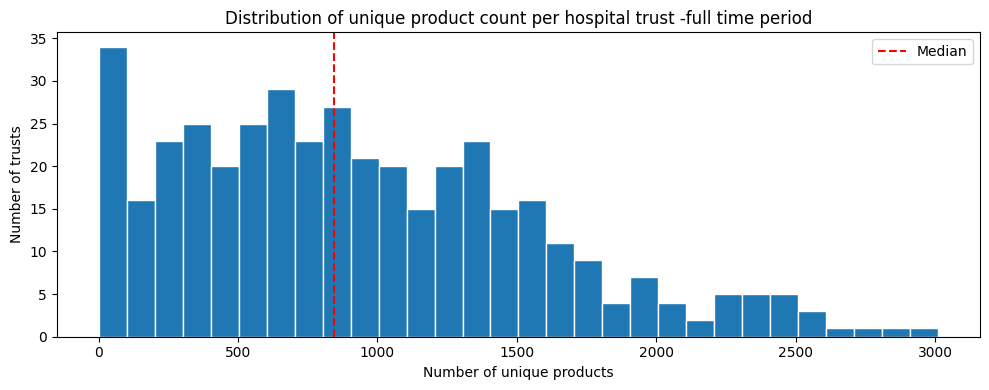

In [55]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_products_per_org["unique_products"], bins=30, edgecolor="white")
ax.set_xlabel("Number of unique products")
ax.set_ylabel("Number of trusts")
ax.set_title("Distribution of unique product count per hospital trust -full time period")
ax.axvline(df_products_per_org["unique_products"].median(), color="red", linestyle="--", label="Median")
ax.legend()
plt.tight_layout()
plt.show()

In [48]:
# ── Top 20 products for each of the top 20 trusts ───────────────────
sql_top_orgs_breakdown = f"""
WITH top_orgs AS (
  SELECT
    rx.HOSPITAL_TRUST_CODE,
    rx.HOSPITAL_TRUST,
    COUNT(DISTINCT bnf.product_code) AS unique_products
  FROM `{TABLE_ID}` rx
  LEFT JOIN `hscic.bnf` bnf
    ON rx.BNF_CODE = bnf.presentation_code
  GROUP BY 1, 2
  ORDER BY unique_products DESC
  LIMIT 20
)
SELECT
  t.HOSPITAL_TRUST_CODE,
  t.HOSPITAL_TRUST,
  bnf.product_code,
  bnf.product,
  bnf.chapter,
  SUM(rx.TOTAL_ITEMS) AS total_items,
  SUM(rx.TOTAL_ACTUAL_COST) AS total_cost
FROM `{TABLE_ID}` rx
INNER JOIN top_orgs t
  ON rx.HOSPITAL_TRUST_CODE = t.HOSPITAL_TRUST_CODE
LEFT JOIN `hscic.bnf` bnf
  ON rx.BNF_CODE = bnf.presentation_code
GROUP BY 1, 2, 3, 4, 5
QUALIFY ROW_NUMBER() OVER (PARTITION BY t.HOSPITAL_TRUST_CODE ORDER BY SUM(rx.TOTAL_ITEMS) DESC) <= 20
ORDER BY t.HOSPITAL_TRUST, total_items DESC
"""

df_top_orgs = bq.cached_read(sql_top_orgs_breakdown, csv_path=os.path.join(CACHE_DIR, "top_orgs_breakdown.csv"))

fmt = {"total_items": "{:,.0f}", "total_cost": "{:,.2f}"}

for trust_code, group in df_top_orgs.groupby("HOSPITAL_TRUST_CODE"):
    trust_name = group["HOSPITAL_TRUST"].iloc[0]
    print(f"\n{'='*80}")
    print(f"{trust_name} ({trust_code})")
    print(f"{'='*80}")
    display(group[["product", "chapter", "total_items", "total_cost"]].reset_index(drop=True).style.format(fmt))

Downloading: 100%|█████████████████████████████████████████████████████████████|

WALSALL HEALTHCARE NHS TRUST (RBK00)


,product,chapter,total_items,total_cost
0,Folic acid,Nutrition and Blood,"7,054","7,355.92"
1,Prednisolone (Systemic),Endocrine System,"6,711","37,461.26"
2,Co-amoxiclav,Infections,"6,631","27,340.19"
3,Ozempic,Endocrine System,"6,092","966,086.39"
4,Omeprazole,Gastro-Intestinal System,"5,895","115,098.80"
5,Flucloxacillin sodium,Infections,"4,569","28,487.32"
6,Bisoprolol fumarate,Cardiovascular System,"4,492","3,438.02"
7,Proprietary compound emollients,Skin,"4,208","25,496.50"
8,None,None,"4,143","136,508.91"
9,Methotrexate (Rheumatism),Musculoskeletal and Joint Diseases,"4,080","35,156.32"



BEDFORDSHIRE HOSPITALS NHS FOUNDATION TRUST (RC900)


,product,chapter,total_items,total_cost
0,Prednisolone (Systemic),Endocrine System,"25,277","134,954.81"
1,Omeprazole,Gastro-Intestinal System,"21,051","124,666.56"
2,Folic acid,Nutrition and Blood,"20,597","31,243.81"
3,Co-amoxiclav,Infections,"16,111","55,715.77"
4,Methotrexate (Rheumatism),Musculoskeletal and Joint Diseases,"15,131","54,362.19"
5,Bisoprolol fumarate,Cardiovascular System,"14,637","10,112.41"
6,Isotretinoin (Systemic),Skin,"10,815","299,466.68"
7,Aspirin (Antiplatelet),Cardiovascular System,"10,701","15,928.94"
8,Colecalciferol,Nutrition and Blood,"10,643","153,796.42"
9,Lansoprazole,Gastro-Intestinal System,"10,475","18,734.06"



FRIMLEY HEALTH NHS FOUNDATION TRUST (RDU00)


...

,product,chapter,total_items,total_cost
0,Chloramphenicol (Eye),Eye,"54,371","279,840.69"
1,Prednisolone (Systemic),Endocrine System,"43,693","209,229.00"
2,Thealoz Duo eye drops preservative free,Appliances,"38,165","562,979.89"
3,Hylo-Forte 0.2% eye drops preservative free,Appliances,"34,090","441,201.92"
4,Co-amoxiclav,Infections,"31,837","96,365.24"
5,Folic acid,Nutrition and Blood,"30,787","44,318.90"
6,Methotrexate (Rheumatism),Musculoskeletal and Joint Diseases,"27,857","193,033.55"
7,Co-codamol,Central Nervous System,"27,747","58,811.22"
8,Lansoprazole,Gastro-Intestinal System,"22,952","40,020.06"
9,Dexafree,Eye,"22,784","727,351.74"



CO.DURHAM & DARLINGTON NHS FOUNDATION TR (RXP00)


,product,chapter,total_items,total_cost
0,Prednisolone (Systemic),Endocrine System,"23,525","102,018.31"
1,Folic acid,Nutrition and Blood,"21,806","21,155.06"
2,Methotrexate (Rheumatism),Musculoskeletal and Joint Diseases,"21,727","125,722.65"
3,Isotretinoin (Systemic),Skin,"16,847","571,534.13"
4,Co-amoxiclav,Infections,"14,222","56,601.40"
5,Omeprazole,Gastro-Intestinal System,"10,357","195,492.22"
6,Amoxicillin,Infections,"7,935","30,308.10"
7,Doxycycline hyclate (Antibacterial),Infections,"7,446","29,761.46"
8,Acitretin,Skin,"7,386","542,743.86"
9,Flucloxacillin sodium,Infections,"7,046","39,511.45"



UNIDENTIFIED TRUST (Y999666)


,product,chapter,total_items,total_cost
0,Amoxicillin,Infections,"1,197","1,842.53"
1,Methadone hydrochloride (Drug Dependence),Central Nervous System,"1,132","6,958.29"
2,Prednisolone (Systemic),Endocrine System,"1,120","3,620.42"
3,Flucloxacillin sodium,Infections,"1,112","4,519.66"
4,Co-amoxiclav,Infections,972,"2,689.90"
5,Co-codamol,Central Nervous System,872,"2,026.69"
6,Omeprazole,Gastro-Intestinal System,766,"5,342.43"
7,Naproxen,Musculoskeletal and Joint Diseases,676,"1,803.62"
8,Diazepam,Central Nervous System,668,"1,787.23"
9,Quetiapine,Central Nervous System,631,"7,826.48"


# Product by Organisation -latest month

Because date is an interger, we will convert it to a date. PARSE_DATE('%Y%m', CAST(PERIOD AS STRING)) converts the integer (e.g. 202402) into a proper date (2024-02-01), and the subquery in the WHERE clause automatically picks the most recent month in the dataset.

In [53]:
# ── How many unique products does each trust prescribe? (latest month) ──
sql_products_per_org_latest_month = f"""
SELECT
  PARSE_DATE('%Y%m', CAST(rx.PERIOD AS STRING)) AS period_date,
  rx.HOSPITAL_TRUST_CODE,
  rx.HOSPITAL_TRUST,
  COUNT(DISTINCT bnf.product_code) AS unique_products
FROM `{TABLE_ID}` rx
LEFT JOIN `hscic.bnf` bnf
  ON rx.BNF_CODE = bnf.presentation_code
WHERE rx.PERIOD = (SELECT MAX(PERIOD) FROM `{TABLE_ID}`)
GROUP BY 1, 2, 3
ORDER BY unique_products DESC
"""

df_products_per_org_latest_month = bq.cached_read(sql_products_per_org_latest_month, csv_path=os.path.join(CACHE_DIR, "products_per_org_latest_month.csv"))
print(f"Period: {df_products_per_org_latest_month['period_date'].iloc[0]}")
print(f"\nSummary of unique products per trust:")
print(df_products_per_org_latest_month["unique_products"].describe().apply("{:,.0f}".format))
print()
display(df_products_per_org_latest_month.head(20).style.format({"unique_products": "{:,.0f}"}))

Downloading: 100%|█████████████████████████████████████████████████████████████|
Period: 2025-09-01

Summary of unique products per trust:
count    190
mean     246
std      209
min        1
25%       89
50%      176
75%      367
max      898
Name: unique_products, dtype: object



,period_date,HOSPITAL_TRUST_CODE,HOSPITAL_TRUST,unique_products
0,2025-09-01,RVV00,EAST KENT HOSPITALS UNIVERSITY NHS FOUNDATION TRUST,898
1,2025-09-01,RC900,BEDFORDSHIRE HOSPITALS NHS FOUNDATION TRUST,854
2,2025-09-01,RTE00,GLOUCESTERSHIRE HOSPITALS NHS FOUNDATION TRUST,851
3,2025-09-01,RXK00,SANDWELL AND WEST BIRMINGHAM HOSPITALS NHS TRUST,837
4,2025-09-01,RYR00,UNIVERSITY HOSPITALS SUSSEX NHS FOUNDATION TRUST,802
5,2025-09-01,RF400,BARKING HAVERING AND REDBRIDGE UNIVERSITY HOSPITALS NHS TRUST,770
6,2025-09-01,RXP00,COUNTY DURHAM AND DARLINGTON NHS FOUNDATION TRUST,703
7,2025-09-01,RDU00,FRIMLEY HEALTH NHS FOUNDATION TRUST,694
8,2025-09-01,RP500,DONCASTER AND BASSETLAW TEACHING HOSPITALS NHS FOUNDATION TRUST,674
9,2025-09-01,RK500,SHERWOOD FOREST HOSPITALS NHS FOUNDATION TRUST,662


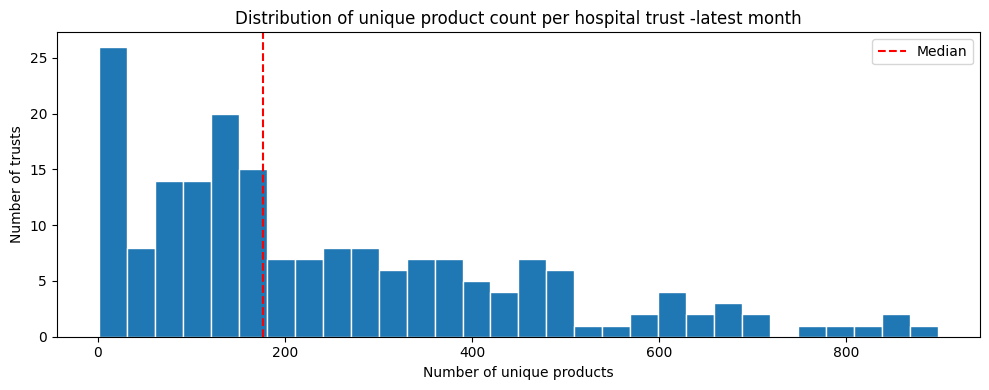

In [54]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_products_per_org_latest_month["unique_products"], bins=30, edgecolor="white")
ax.set_xlabel("Number of unique products")
ax.set_ylabel("Number of trusts")
ax.set_title("Distribution of unique product count per hospital trust -latest month")
ax.axvline(df_products_per_org_latest_month["unique_products"].median(), color="red", linestyle="--", label="Median")
ax.legend()
plt.tight_layout()
plt.show()

## Top 20 products in the latest month 

In [66]:
# ── Top 20 products in the latest month ──────────────────────────────
sql_top_products_latest = f"""
SELECT
  PARSE_DATE('%Y%m', CAST(rx.PERIOD AS STRING)) AS period_date,
  bnf.product_code,
  bnf.product,
  SUM(rx.TOTAL_ITEMS) AS total_items,
  SUM(rx.TOTAL_ACTUAL_COST) AS total_cost
FROM `{TABLE_ID}` rx
LEFT JOIN `hscic.bnf` bnf
  ON rx.BNF_CODE = bnf.presentation_code
WHERE rx.PERIOD = (SELECT MAX(PERIOD) FROM `{TABLE_ID}`)
GROUP BY 1, 2, 3
ORDER BY total_items DESC
LIMIT 20
"""

df_top_products_latest = bq.cached_read(
    sql_top_products_latest,
    csv_path=os.path.join(CACHE_DIR, "top_products_latest.csv")
)

print(f"Period: {df_top_products_latest['period_date'].iloc[0]}")

display(
    df_top_products_latest[["product", "total_items", "total_cost"]]
    .style.format({
        "total_items": "{:,.0f}",
        "total_cost": "£{:,.2f}"
    })
)

Downloading: 100%|█████████████████████████████████████████████████████████████|
Period: 2025-09-01


,product,total_items,total_cost
0,Sertraline hydrochloride,"10,976","£137,425.17"
1,Quetiapine,"10,505","£181,328.74"
2,Prednisolone (Systemic),"10,103","£65,903.20"
3,Methadone hydrochloride (Drug Dependence),"9,876","£53,924.38"
4,Co-amoxiclav,"9,196","£20,643.71"
5,Methylphenidate hydrochloride,"9,121","£246,721.01"
6,Aripiprazole,"8,844","£62,758.89"
7,Physeptone (Drug Dependence),"8,357","£65,929.14"
8,Melatonin,"8,162","£173,110.23"
9,Omeprazole,"8,006","£89,606.45"


# End of Notebook

ChatGPT and Claude were used to help write the code in this notebook.